In [28]:
# Import libraries
# For question 1
import numpy as np
import pandas as pd
import seaborn as sbn
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
# One dataset
# Import data
data = pd.read_excel('Global Style_Exam Data (2026).xlsx', index_col=0)
data.index = pd.to_datetime(data.index)

benchmark   = data['MSCI']
styles      = data.drop(columns=['MSCI'])
style_names = styles.columns.tolist()

## Paired sample t-test: positive average excess return relative to the MSCI benchmark 

In [33]:
# paired t-test
ttest_results = []

for style in style_names:
    excess        = styles[style] - benchmark
    mean_exc      = excess.mean()
    std_exc       = excess.std()
    t_stat, p_two = stats.ttest_rel(styles[style], benchmark)

    # One-sided p-value: testing for positive excess return
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    ttest_results.append({
        'Style'                      : style,
        'Mean Excess Ret (% p.m.)'   : round(mean_exc * 100, 4),
        'Std Dev (%)'                : round(std_exc  * 100, 4),
        't-statistic'                : round(t_stat,  4),
        'p-value (two-sided)'        : round(p_two,   4),
        'p-value (one-sided)'        : round(p_one,   4),
        'Positive Excess'            : mean_exc > 0,
        'Significant @ 5% (1-sided)' : p_one < 0.05
    })

ttest_df = pd.DataFrame(ttest_results).set_index('Style')
print("Paired T-Test Results (Style vs MSCI Benchmark):")
print(ttest_df.to_string())

Paired T-Test Results (Style vs MSCI Benchmark):
          Mean Excess Ret (% p.m.)  Std Dev (%)  t-statistic  p-value (two-sided)  p-value (one-sided)  Positive Excess  Significant @ 5% (1-sided)
Style                                                                                                                                              
Growth                      0.0297       1.2741       0.4149               0.6785               0.3393             True                       False
DY                         -0.0119       1.7876      -0.1184               0.9058               0.5471            False                       False
Big                        -0.0242       0.2901      -1.4800               0.1399               0.9301            False                       False
Med                         0.0821       1.3788       1.0591               0.2903               0.1452             True                       False
Low Vol                    -0.0307       2.2366      -0.2437   

Summary of Paired T-Test Results:
Significant positive excess return: Quality  (mean=0.1212%, p=0.0388)
Significant positive excess return: Small  (mean=0.2167%, p=0.0356)
Positive but not significant: Growth  (mean=0.0297%, p=0.3393)
Positive but not significant: Med  (mean=0.0821%, p=0.1452)
Positive but not significant: Momentum  (mean=0.1566%, p=0.1057)
Negative mean excess return: DY  (mean=-0.0119%, p=0.5471)
Negative mean excess return: Big  (mean=-0.0242%, p=0.9301)
Negative mean excess return: Low Vol  (mean=-0.0307%, p=0.5962)
Negative mean excess return: Value  (mean=-0.0402%, p=0.7108)


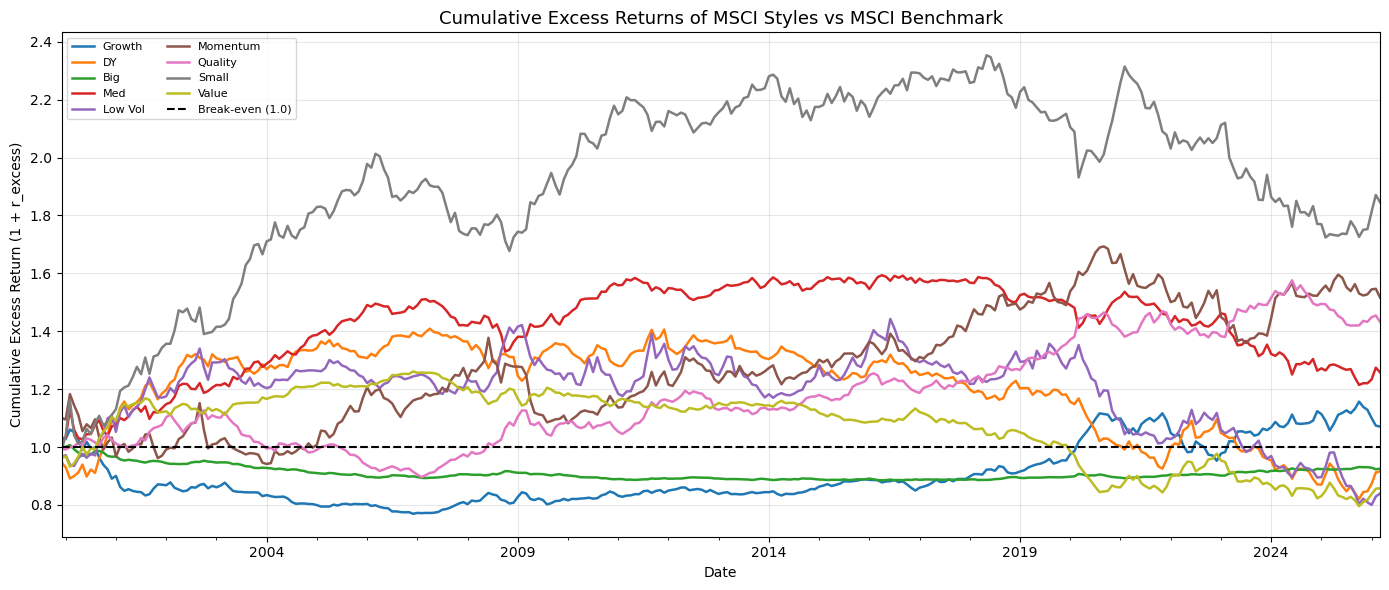

In [35]:
# t-test summary
print("Summary of Paired T-Test Results:")
sig_pos  = ttest_df[(ttest_df['Significant @ 5% (1-sided)']) & (ttest_df['Positive Excess'])]
pos_only = ttest_df[(~ttest_df['Significant @ 5% (1-sided)']) & (ttest_df['Positive Excess'])]
neg      = ttest_df[~ttest_df['Positive Excess']]

for s in sig_pos.index:
    print(f"Significant positive excess return: {s}  "
          f"(mean={ttest_df.loc[s,'Mean Excess Ret (% p.m.)']:.4f}%, "
          f"p={ttest_df.loc[s,'p-value (one-sided)']:.4f})")
for s in pos_only.index:
    print(f"Positive but not significant: {s}  "
          f"(mean={ttest_df.loc[s,'Mean Excess Ret (% p.m.)']:.4f}%, "
          f"p={ttest_df.loc[s,'p-value (one-sided)']:.4f})")
for s in neg.index:
    print(f"Negative mean excess return: {s}  "
          f"(mean={ttest_df.loc[s,'Mean Excess Ret (% p.m.)']:.4f}%, "
          f"p={ttest_df.loc[s,'p-value (one-sided)']:.4f})")

# plot
excess_df = styles.subtract(benchmark, axis='rows')
fig, ax = plt.subplots(figsize=(14, 6))
(1 + excess_df).cumprod().plot(ax=ax, linewidth=1.8)
ax.axhline(1, color='black', linestyle='--', linewidth=1.5, label='Break-even (1.0)')
ax.set_title('Cumulative Excess Returns of MSCI Styles vs MSCI Benchmark', fontsize=13)
ax.set_ylabel('Cumulative Excess Return (1 + r_excess)')
ax.set_xlabel('Date')
ax.legend(loc='best', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1_excess_returns.png', dpi=150)
plt.show()

**Commentary**

From the paired t-test, we can see that Quality and Small are the only styles that have positive excess returns relative to the MSCI benchmark over the given sample period. This is because their p_values are statistically significant at a 5% level of significance (p < 0.05). This implies that theses two styles outperformed the market instead of just benefiting from the market movements. 

Quality has a mean monthly excess return of 0.1212% with a statistically significant p_value of 0.0388
Small has a mean monthly excess return of 0.2167% with a statistically significant p_value of 0.0356. This is the highest mean monthly excess return recorded.

We can also see that Momentum has a higher mean monthly excess return compared to Quality (0.1566% vs 0.1212%), but this is not statistically significant because Momentum has a p_value of 0.1057 > 0.05. This could be because Momentum has a higher standard deviation compared to Quality (2.2219% vs 1.2164%). This is confirmed by the Cumulative Excess Returns of MSCI Styles vs MSCI Benchmark plot above. This means that we cannot rule out that the performance was due to chance rather than skill. 

The Cumulative Excess Returns of MSCI Styles vs MSCI Benchmark confirms that both Quality and Small consistently stayed above the break-even line throughout most of the sample period, unlike other styles that fluctuated more dramatically.

## ANOVA test to see if MSCI styles achieved significantly different returns

In [39]:
# ANOVA 
# Remember: High F_stats means that groups are likely different 
# Remember: High variance might hide differences

anova_groups = [styles[s].dropna().values for s in style_names]
f_stat, p_anova = stats.f_oneway(*anova_groups)

print(f"ANOVA Results:")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.6f}")
print()
if p_anova < 0.05:
    print(" Reject null hypothesis at the 5% significance level because it is statistically significant. This means that MSCI style indices have achieved statistically different returns over the sample period. The variation in average returns across styles is unlikely to have occurred by chance.")
else:
    print("Do not reject null hypothesis at the 5% significance level, because there is no statistically significant difference in returns across MSCI style indices.")

# Summary stats 
print()
desc = styles.describe().T[['mean','std','min','max']].copy()
desc.columns = ['Mean (monthly)', 'Std Dev', 'Min', 'Max']
desc['Ann. Return (%)'] = desc['Mean (monthly)'] * 12 * 100
desc['Ann. Vol (%)']    = desc['Std Dev'] * np.sqrt(12) * 100
print("Descriptive Statistics by Style:")
print(desc[['Mean (monthly)', 'Std Dev', 'Ann. Return (%)', 'Ann. Vol (%)']].round(4).to_string())

ANOVA Results:
  F-statistic : 0.1374
  p-value     : 0.997535

Do not reject null hypothesis at the 5% significance level, because there is no statistically significant difference in returns across MSCI style indices.

Descriptive Statistics by Style:
          Mean (monthly)  Std Dev  Ann. Return (%)  Ann. Vol (%)
Growth            0.0065   0.0477           7.8083       16.5133
DY                0.0061   0.0421           7.3085       14.5892
Big               0.0060   0.0441           7.1616       15.2772
Med               0.0070   0.0491           8.4372       17.0127
Low Vol           0.0059   0.0320           7.0836       11.1012
Momentum          0.0078   0.0452           9.3301       15.6740
Quality           0.0074   0.0415           8.9055       14.3842
Small             0.0084   0.0523          10.0517       18.1079
Value             0.0058   0.0449           6.9689       15.5476


**Commentary**

The ANOVA test yields an F-statistic of 0.1374, meaning that the ANOVA groups are likely similar. We gat a p_value of 0.997535, which is > 0.05. This means that we do not reject the null hypothesis at the 5% significance level, because there is no statistically significant difference in returns across MSCI style indices. Our high p_value implies that the between-group variance is very small relative to the within-group variance. Meaning that the natural month-to-month volatility within each style is so large that it swamps any differences in average returns across styles.

This means that we cannot conclude that any style consistently outperforms another based solely on mean returns because the differences are not statistically reliable.

## Time-series OLS regression on each style and comment on 
    a. Alpha
    b. Beta
    c. R squared

In [43]:
# recall assignmnet q3
# OLS
# Alpha = excess return after controlling for market (intercept)
# Beta = market sensitivity (slope coefficient)

ols_results = {}
X_bench = sm.add_constant(benchmark)
X_bench.columns = ['const', 'MSCI']

for style in style_names:
    model = sm.OLS(styles[style], X_bench).fit()
    ols_results[style] = model

# summary
summary_rows = []
for style in style_names:
    m = ols_results[style]
    sig = '***' if m.pvalues['const'] < 0.01 else ('**' if m.pvalues['const'] < 0.05
          else ('*' if m.pvalues['const'] < 0.10 else 'ns'))
    summary_rows.append({
        'Style'          : style,
        'Alpha (monthly)': round(m.params['const'], 6),
        'Alpha p-val'    : round(m.pvalues['const'], 4),
        'Sig'            : sig,
        'Beta'           : round(m.params['MSCI'],  4),
        'Beta p-val'     : round(m.pvalues['MSCI'], 4),
        'R squared'             : round(m.rsquared,     4),
        'Adj R squared'         : round(m.rsquared_adj, 4),
    })

ols_df = pd.DataFrame(summary_rows).set_index('Style')
print("OLS Regression Summary (each Style vs MSCI benchmark):")
print(ols_df.to_string())
print()
print(" Significance codes:  *** p<0.01   ** p<0.05   * p<0.10   ns = not significant")

OLS Regression Summary (each Style vs MSCI benchmark):
          Alpha (monthly)  Alpha p-val  Sig    Beta  Beta p-val  R squared  Adj R squared
Style                                                                                    
Growth           0.000085       0.9061   ns  1.0342         0.0     0.9296         0.9294
DY               0.000700       0.4671   ns  0.8682         0.0     0.8392         0.8387
Big             -0.000181       0.2679   ns  0.9903         0.0     0.9958         0.9958
Med              0.000433       0.5731   ns  1.0625         0.0     0.9244         0.9241
Low Vol          0.001970       0.0245   **  0.6334         0.0     0.7714         0.7707
Momentum         0.002228       0.0722    *  0.8933         0.0     0.7698         0.7691
Quality          0.001839       0.0045  ***  0.8991         0.0     0.9259         0.9256
Small            0.001688       0.1588   ns  1.0771         0.0     0.8385         0.8380
Value           -0.000205       0.7785   ns  

In [45]:
# Per-style OLS detail 
print("Detailed OLS Results per Style:")
for style in style_names:
    m = ols_results[style]
    sig = 'Significant' if m.pvalues['const'] < 0.05 else 'Not significant'
    print(f"\nStyle : {style}")
    print(f"  α  = {m.params['const']:+.6f}  (p = {m.pvalues['const']:.4f})  → {sig}")
    print(f"  β  = {m.params['MSCI']:+.4f}   (p = {m.pvalues['MSCI']:.4f})")
    print(f"  R² = {m.rsquared:.4f}   Adj R² = {m.rsquared_adj:.4f}")

ols_df = pd.DataFrame(summary_rows).set_index('Style')

print(ols_df.to_string())
print(f"Average R²: {ols_df['R squared'].mean():.4f}")
print(f"Average Adj R²: {ols_df['Adj R squared'].mean():.4f}")

Detailed OLS Results per Style:

Style : Growth
  α  = +0.000085  (p = 0.9061)  → Not significant
  β  = +1.0342   (p = 0.0000)
  R² = 0.9296   Adj R² = 0.9294

Style : DY
  α  = +0.000700  (p = 0.4671)  → Not significant
  β  = +0.8682   (p = 0.0000)
  R² = 0.8392   Adj R² = 0.8387

Style : Big
  α  = -0.000181  (p = 0.2679)  → Not significant
  β  = +0.9903   (p = 0.0000)
  R² = 0.9958   Adj R² = 0.9958

Style : Med
  α  = +0.000433  (p = 0.5731)  → Not significant
  β  = +1.0625   (p = 0.0000)
  R² = 0.9244   Adj R² = 0.9241

Style : Low Vol
  α  = +0.001970  (p = 0.0245)  → Significant
  β  = +0.6334   (p = 0.0000)
  R² = 0.7714   Adj R² = 0.7707

Style : Momentum
  α  = +0.002228  (p = 0.0722)  → Not significant
  β  = +0.8933   (p = 0.0000)
  R² = 0.7698   Adj R² = 0.7691

Style : Quality
  α  = +0.001839  (p = 0.0045)  → Significant
  β  = +0.8991   (p = 0.0000)
  R² = 0.9259   Adj R² = 0.9256

Style : Small
  α  = +0.001688  (p = 0.1588)  → Not significant
  β  = +1.0771   (p =

In [47]:
# Key findings
best_alpha_style = ols_df['Alpha (monthly)'].idxmax()  # This returns the index (Style)
best_alpha = ols_df['Alpha (monthly)'].max()
print(f"\nBest Alpha: {best_alpha_style} ({best_alpha:.6f})")

sig_alphas = ols_df[ols_df['Alpha p-val'] < 0.05]
print(f"Styles with significant alpha (p<0.05): {len(sig_alphas)}")
print(f"  → {', '.join(sig_alphas.index.tolist())}")  # Use .index since Style is the index

best_r2_style = ols_df['R squared'].idxmax()
best_r2 = ols_df['R squared'].max()
print(f"\nBest R²: {best_r2_style} ({best_r2:.4f})")
print(f"Average R²: {ols_df['R squared'].mean():.4f}")

# Which styles have beta significantly different from 1?
print(f"\nStyles with Beta not equal to 1 (p<0.05):")
for style in style_names:
    m = ols_results[style]
    # Test if beta != 1
    t_stat = (m.params['MSCI'] - 1) / m.bse['MSCI']
    p_beta_ne_1 = 2 * (1 - stats.t.cdf(abs(t_stat), df=m.df_resid))
    if p_beta_ne_1 < 0.05:
        print(f"  {style}: β={m.params['MSCI']:.4f} (p={p_beta_ne_1:.4f})")


Best Alpha: Momentum (0.002228)
Styles with significant alpha (p<0.05): 2
  → Low Vol, Quality

Best R²: Big (0.9958)
Average R²: 0.8793

Styles with Beta not equal to 1 (p<0.05):
  Growth: β=1.0342 (p=0.0340)
  DY: β=0.8682 (p=0.0000)
  Big: β=0.9903 (p=0.0080)
  Med: β=1.0625 (p=0.0003)
  Low Vol: β=0.6334 (p=0.0000)
  Momentum: β=0.8933 (p=0.0001)
  Quality: β=0.8991 (p=0.0000)
  Small: β=1.0771 (p=0.0041)


**Commentary**

Each style return was regressed to analyse each alpha, beta and R squared

a. Alphs:

Only two styles, namely Low Vol (p=0.0245) and Quality (p=0.0045), produced a statistically significant alpha at the 5% level of significance. Momentum has the highest alpha of 0.2228% per month. This suggests modest but statistically significant outperformance

The other styles alphas are not statistically significant.

b. Beta:

We can see that all the styles have betas that are statistically significant at the 5% level of significance. Their p_values are < 0.001 and these betas range from 0.6334 (Low Vol) to 1.0771 (Small). Low Vol exhibits defensive characteristics, while Small, Med and Growth are more aggressive because their betas are larger than 1. Big's beta is approximately  1 (0.990), making it nearly a pure market proxy.

c R squared: 

The R² values are generally high (averaging 0.8793), which indicates that market movements explain most of the variation in style returns. Big has the highest R² at 0.9958 and this means that its returns are almost entirely driven by the benchmark.


## Which one performed the best and why

In [52]:
perf_rows = []
for style in style_names:
    m   = ols_results[style]
    exc = styles[style] - benchmark
    perf_rows.append({
        'Style'              : style,
        'Alpha (ann. bps)'   : m.params['const'] * 12 * 10000,   # annualised basis points
        'Alpha Sig'          : m.pvalues['const'] < 0.05,
        'Beta'               : m.params['MSCI'],
        'R²'                 : m.rsquared,
        'Ann. Return (%)'    : styles[style].mean() * 12 * 100,
        'Ann. Vol (%)'       : styles[style].std() * np.sqrt(12) * 100,
        'Sharpe (ann.)'      : (styles[style].mean() / styles[style].std()) * np.sqrt(12),
        'Info Ratio (ann.)'  : (exc.mean() / exc.std()) * np.sqrt(12) if exc.std() > 0 else 0,
    })

perf_df = pd.DataFrame(perf_rows).set_index('Style')
print("Performance Scorecard:")
print(perf_df.round(4).to_string())

# Key findings
print()
print("Key Metrics:")
print(f"  Highest Alpha (ann.)   : {perf_df['Alpha (ann. bps)'].idxmax()}  "
      f"({perf_df['Alpha (ann. bps)'].max():.1f} bps/year)")
print(f"  Highest R²             : {perf_df['R²'].idxmax()}  "
      f"(R²={perf_df['R²'].max():.4f})")
print(f"  Highest Info Ratio     : {perf_df['Info Ratio (ann.)'].idxmax()}  "
      f"({perf_df['Info Ratio (ann.)'].max():.4f})")
print(f"  Highest Sharpe Ratio   : {perf_df['Sharpe (ann.)'].idxmax()}  "
      f"({perf_df['Sharpe (ann.)'].max():.4f})")

sig_styles = perf_df[perf_df['Alpha Sig'] == True]
print()
print(f"Styles with statistically significant alpha (p < 0.05): {len(sig_styles)}")
for s in sig_styles.index:
    print(f"  → {s}  α={sig_styles.loc[s,'Alpha (ann. bps)']:.1f} bps/yr  "
          f"p={ols_df.loc[s,'Alpha p-val']:.4f}")

# Overall best (prioritise: significant alpha > highest alpha > best info ratio)
if len(sig_styles) > 0:
    best = sig_styles['Alpha (ann. bps)'].idxmax()
    reason = "highest statistically significant alpha"
else:
    best = perf_df['Info Ratio (ann.)'].idxmax()
    reason = "best information ratio (no styles achieved significant alpha)"

print()
print(f"  Best performing style: {best}")
print(f"    Reason : {reason}")
print(f"    Alpha  : {perf_df.loc[best,'Alpha (ann. bps)']:.1f} bps/year  "
      f"({'significant' if perf_df.loc[best,'Alpha Sig'] else 'not significant'})")
print(f"    Beta   : {perf_df.loc[best,'Beta']:.4f}")
print(f"    R²     : {perf_df.loc[best,'R²']:.4f}")
print(f"    Sharpe : {perf_df.loc[best,'Sharpe (ann.)']:.4f}")

Performance Scorecard:
          Alpha (ann. bps)  Alpha Sig    Beta      R²  Ann. Return (%)  Ann. Vol (%)  Sharpe (ann.)  Info Ratio (ann.)
Style                                                                                                                 
Growth             10.1940      False  1.0342  0.9296           7.8083       16.5133         0.4728             0.0808
DY                 83.9553      False  0.8682  0.8392           7.3085       14.5892         0.5010            -0.0231
Big               -21.7356      False  0.9903  0.9958           7.1616       15.2772         0.4688            -0.2884
Med                52.0042      False  1.0625  0.9244           8.4372       17.0127         0.4959             0.2064
Low Vol           236.4173       True  0.6334  0.7714           7.0836       11.1012         0.6381            -0.0475
Momentum          267.3531      False  0.8933  0.7698           9.3301       15.6740         0.5953             0.2441
Quality           220.622

**Commentary**

Based on the regression analysis, Low Vol is the best-performing style over the sample period for two main reasons:

Number one, it has the highest statistically significant alpha of 236.4173 and a p_value of 0.0245. This means that even after accounting for its low beta of 0.63, it still generated excess returns that cannot be explained by market exposure alone. The scond reason is that its Sharpe ratio of 0.6381 is the highest among all styles. This indicates superior risk-adjusted returns. While Small and Momentum had higher raw returns, they also had much higher volatility which resulted in them having lower Sharpe ratios.

Quality also performed well. It has a significant alpha of 2.21% per year and a p_value of 0.0045. However because of its low returns, it the second best performing style. 

When choosing between Low Vol and Quality, you will need to first look at the investors risk tolerance ultimately depends on an investor's risk tolerance, but statistically speaking, one would choose Low Vol because of its significant alpha and because it has the highest Sharpe ratio, which will make it a top performer.